### StudentPerformanceFactors
- 6607행 × 20열
- target : Exam_score

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [60]:
# 데이터 불러오기
df=pd.read_csv("data/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [61]:
# 데이터 구조 및 변수 확인
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.info())

(6607, 20)
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98        

In [62]:
# 수치형 데이터
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


- 일부 변수는 최댓값이 높아 이상치 존재 가능성

In [63]:
# 범주형 데이터 요약
df.describe(include=['string'])

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


In [64]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("수치형 변수:", numeric_cols)
print("범주형 변수:", categorical_cols)

수치형 변수: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
범주형 변수: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [65]:
print(df.value_counts('Parental_Involvement'))
print(df.value_counts('Access_to_Resources'))
print(df.value_counts('Extracurricular_Activities'))
print(df.value_counts('Motivation_Level'))
print(df.value_counts('Internet_Access'))
print(df.value_counts('Family_Income'))
print(df.value_counts('Teacher_Quality'))
print(df.value_counts('School_Type'))
print(df.value_counts('Peer_Influence'))
print(df.value_counts('Learning_Disabilities'))
print(df.value_counts('Parental_Education_Level'))
print(df.value_counts('Distance_from_Home'))
print(df.value_counts('Gender'))

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64
School_Type
Public     4598
Private    2009
Name: count, dtype: int64
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64
Distance_from_Home
Near        3884
Moderate    1998
Far          

In [66]:
print(df.duplicated().sum())          

0


In [67]:
print(df.isna().sum()) 
# 결측치 : Teacher_Quality, Parental_Education_Level, Distance_from_Home 

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


## 이상치 탐지

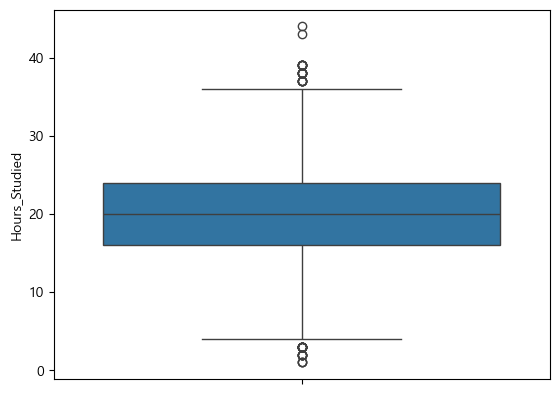

In [68]:
sns.boxplot(df, y="Hours_Studied", whis=1.5)
plt.show()
# 높은 값이 존재

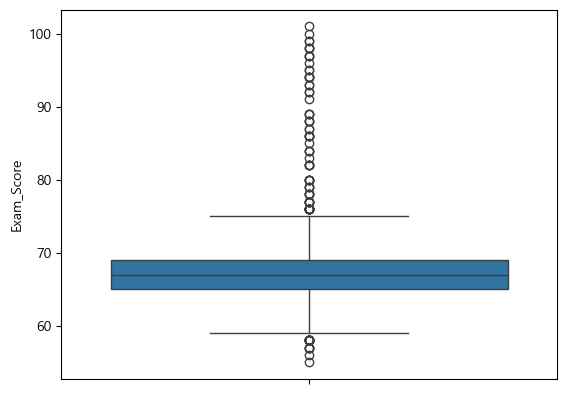

In [69]:
sns.boxplot(df, y="Exam_Score", whis=1.5)
plt.show()
# 최대값이 100점이 넘음..?

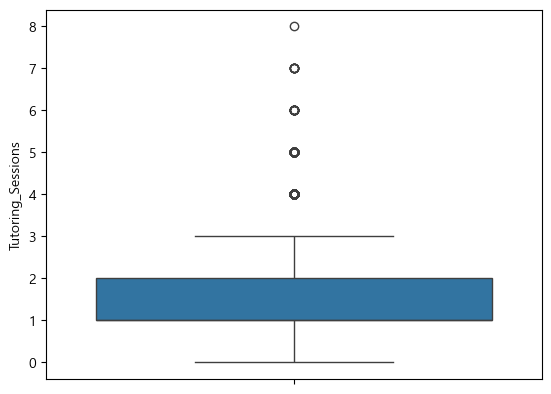

In [70]:
sns.boxplot(df, y="Tutoring_Sessions", whis=1.5)
plt.show()

In [71]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

outliers

Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

- Hours_Studied와 Tutoring_Sessions에서 일부 높은 값
- Exam_Score는 최대값이 100점을 초과하는 값이 존재하여 비현실적인 이상치 -> 100점을 대체

## 수치형 변수 분포 시각화

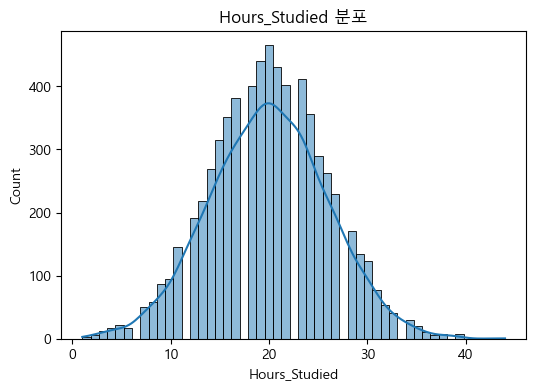

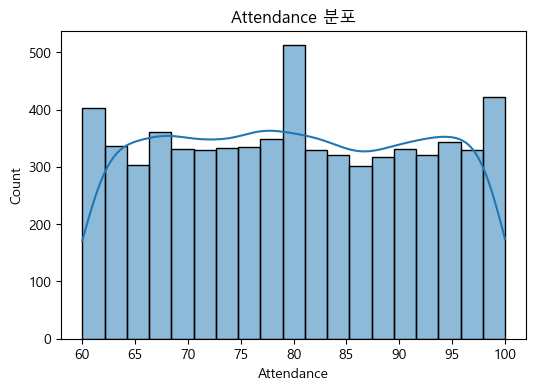

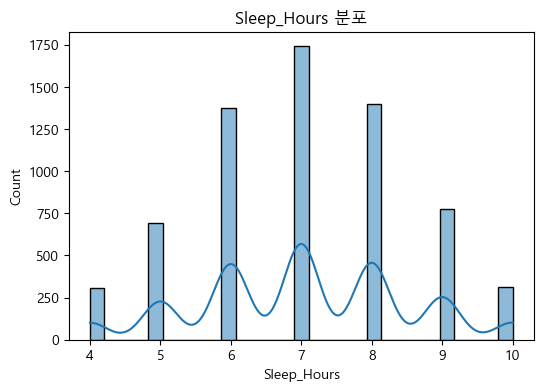

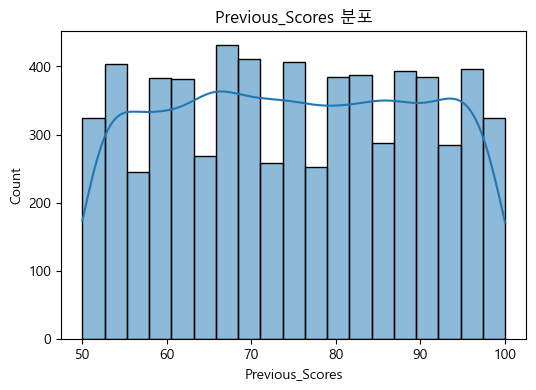

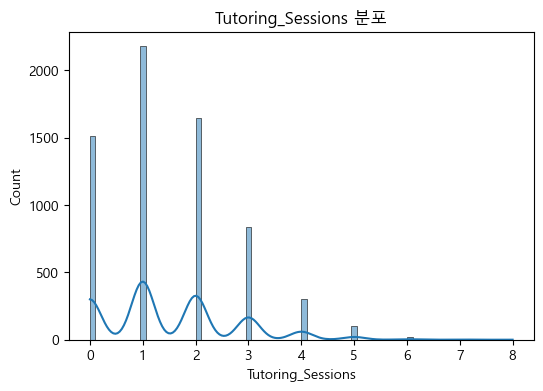

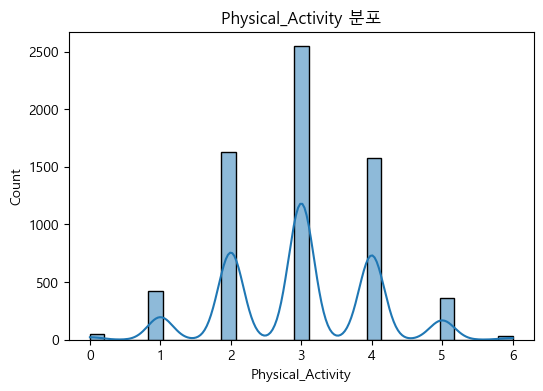

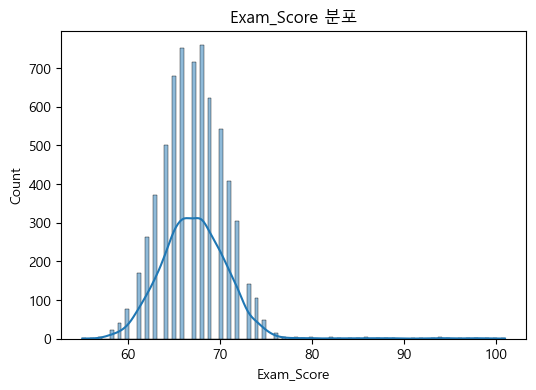

In [72]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 분포")
    plt.show()

- Exam_Score는 60~80 구간에 밀집 -> 정규분포

# 수치형 변수간 관계 시각화

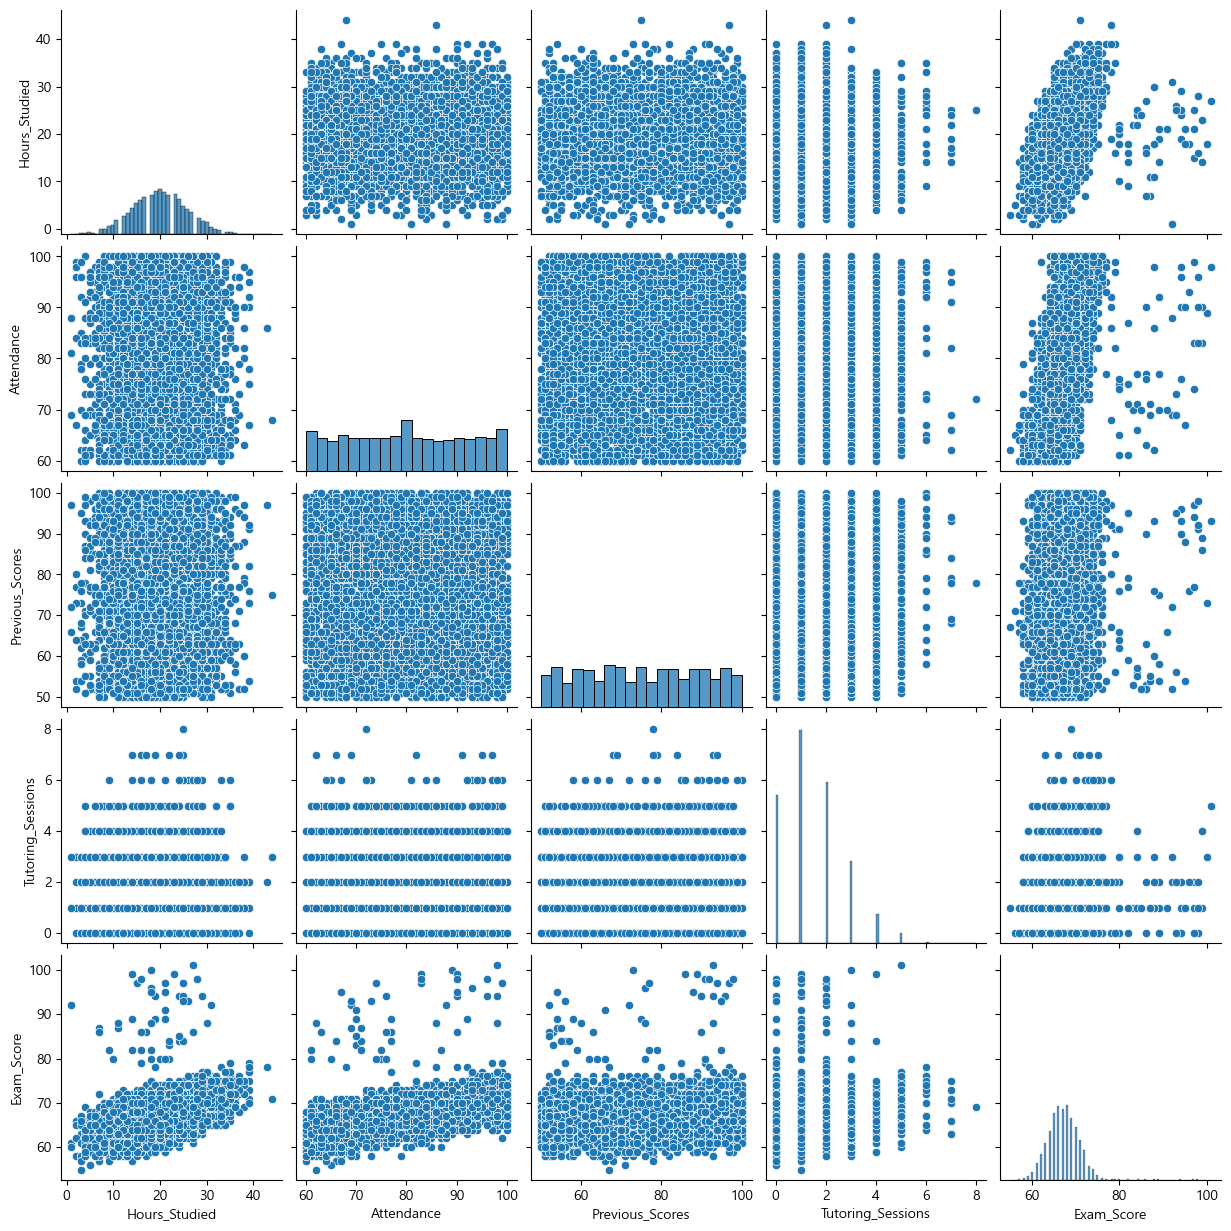

In [73]:
sns.pairplot(
    df[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Exam_Score']]
)
plt.show()

- Attendance와 Hours_Studied는 Exam_Score와 양의 관계.
- Previous_Score도 양의 상관관계
- 반면 Sleep_Hours는 점수와의 관계가 뚜렷하지 않다.

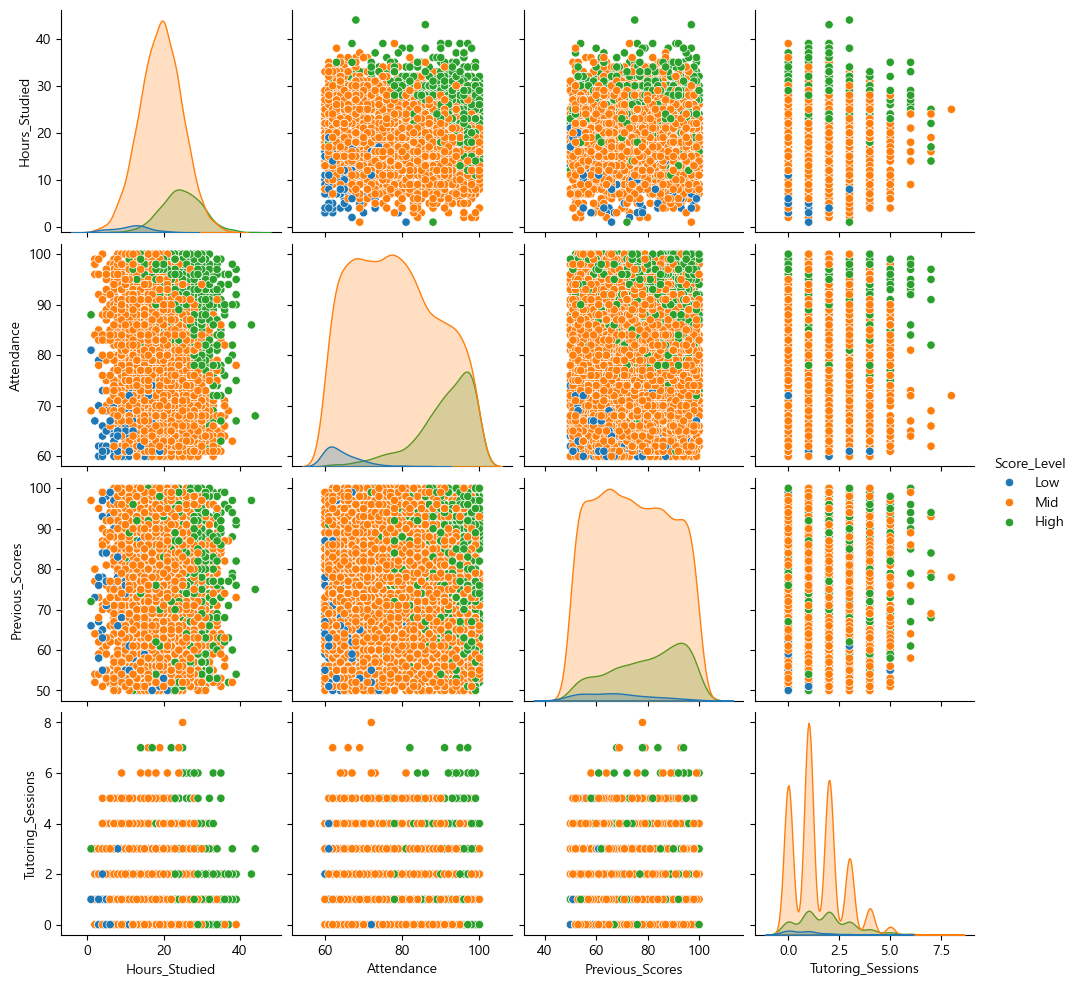

In [74]:
df['Score_Level'] = pd.cut(df['Exam_Score'], bins=[0, 60, 70, 100], labels=['Low', 'Mid', 'High'])

sns.pairplot(
    df[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Score_Level']],
    hue='Score_Level'
)
plt.show()

- Parental_Involvement, Access_to_Resources, Motivation_Level이 높을수록 평균 점수가 높게 나타난다.
- Internet_Access와 Extracurricular_Activities 역시 점수에 긍정적인 영향을 보인다.
- Gender와 School_Type는 점수 차이가 거의 나타나지 않는다.

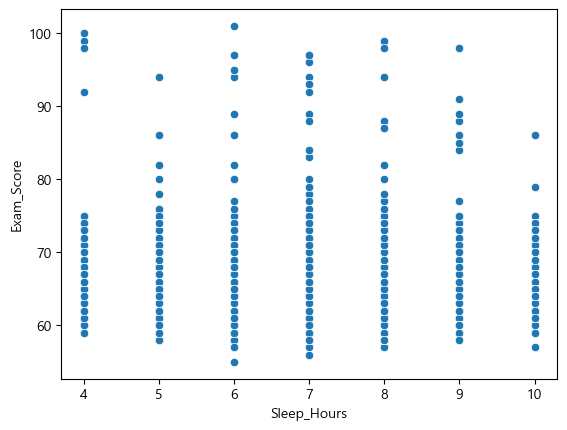

In [75]:
sns.scatterplot(data=df, x="Sleep_Hours", y="Exam_Score")
plt.show()

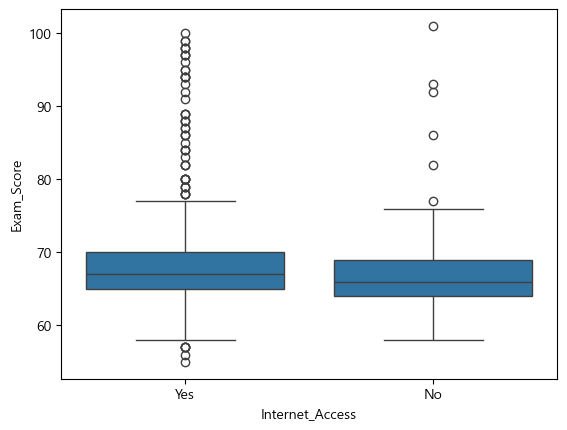

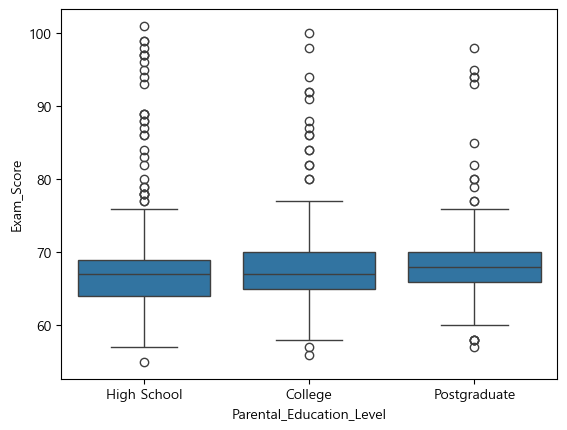

In [76]:
sns.boxplot(data=df, x="Internet_Access", y="Exam_Score")
plt.show()

sns.boxplot(data=df, x="Parental_Education_Level", y="Exam_Score")
plt.show()

- 시험 성적은 학습 습관(출석, 공부 시간 등)에 더 크게 영향을 받으며, 성별이나 학교 유형 같은 변수의 영향은 상대적으로 작게 나타났다.

## 상관관계 분석

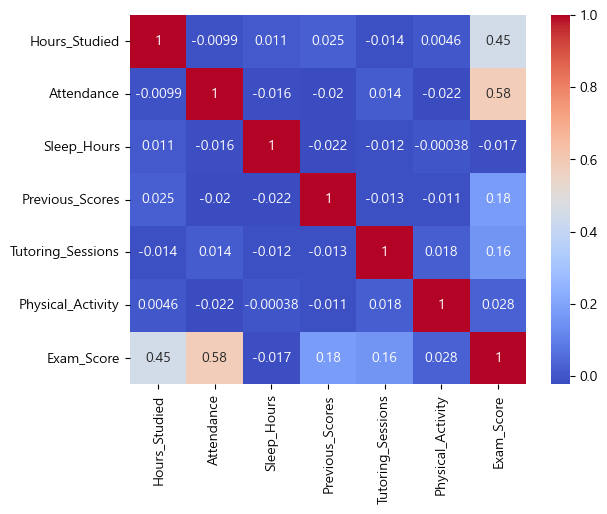

In [77]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

- Exam_Score는 Attendance와 가장 높은 상관관계를 보이며, 그 다음으로 Hours_Studied가 영향을 미친다.
- Previous_Scores와 Tutoring_Sessions는 보조적인 영향을 가지는 것으로 나타났다.

Exam_score를 기준으로 봤을때, 시험 점수는 주로 출석과 공부시간의 영향을 많이 받는다

C:\Users\Playdata\AppData\Local\Temp\ipykernel_16636\1066093319.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


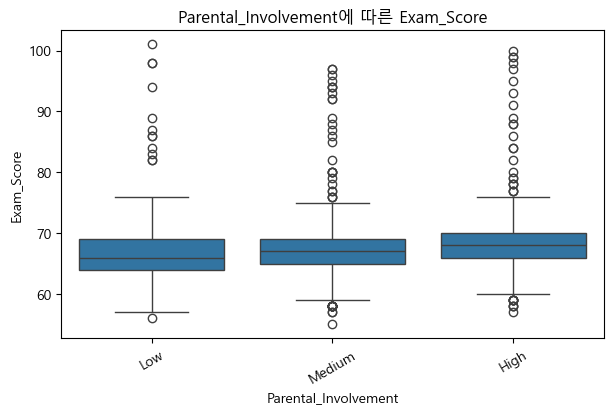

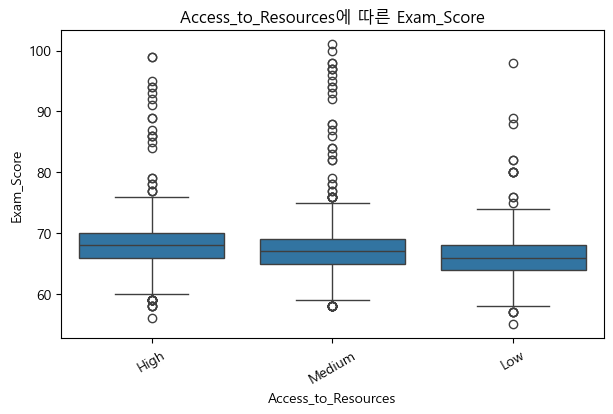

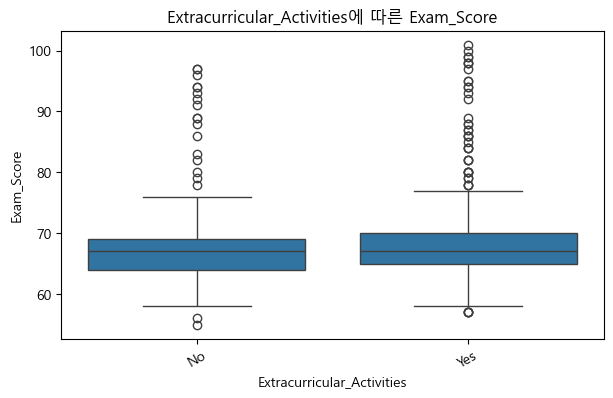

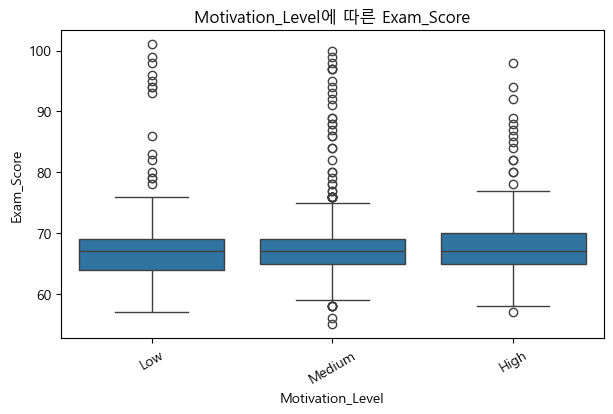

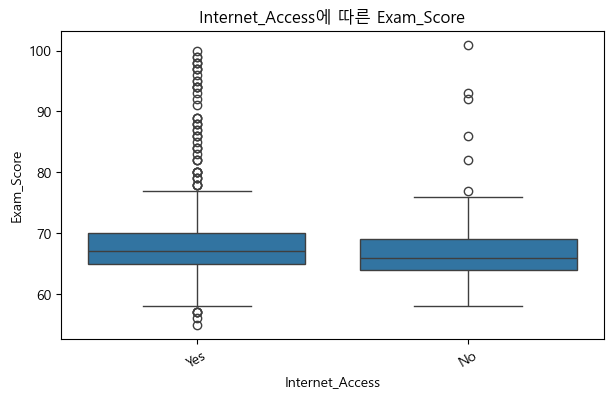

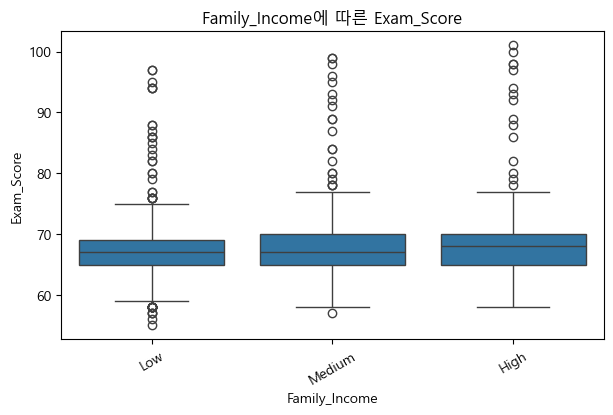

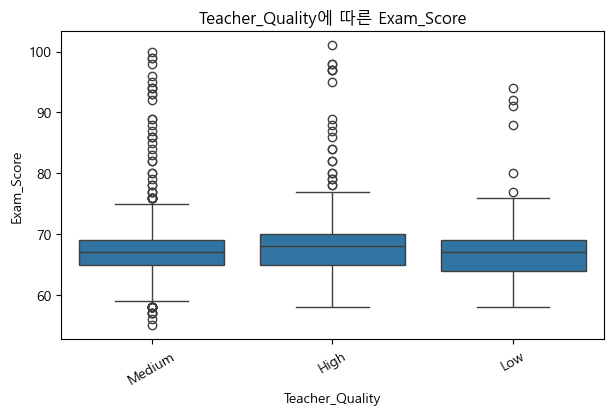

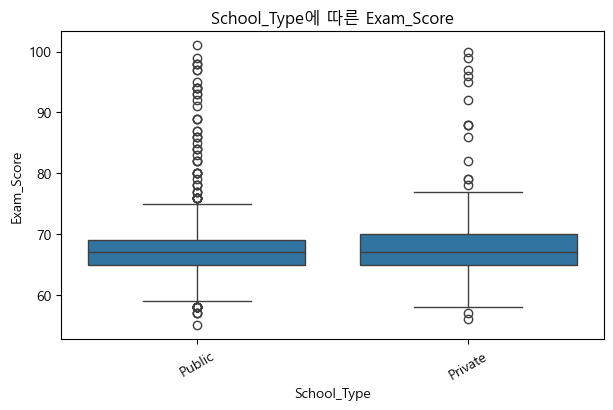

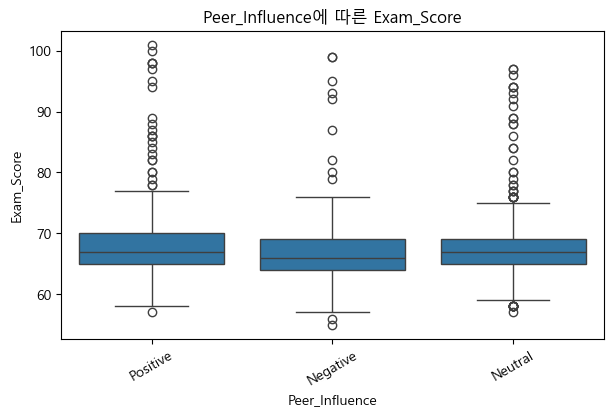

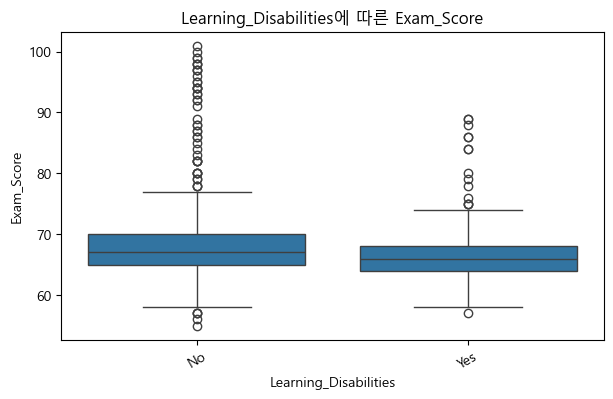

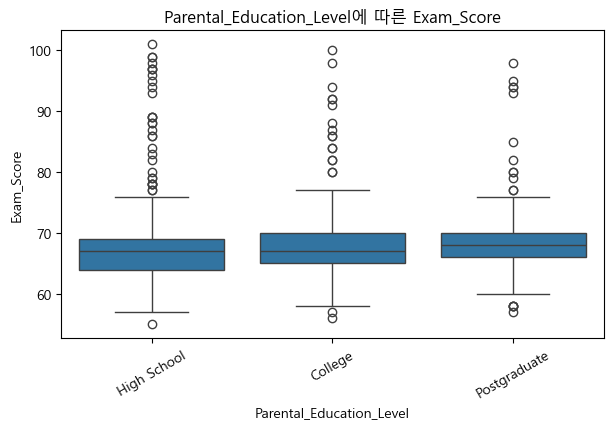

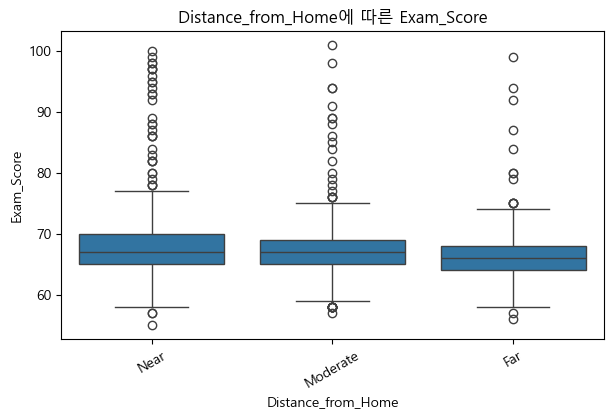

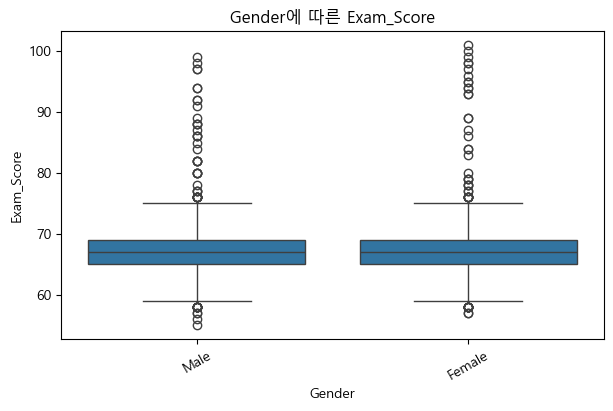

In [78]:
# 범주형 변수
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=col, y='Exam_Score')
    plt.title(f"{col}에 따른 Exam_Score")
    plt.xticks(rotation=30)
    plt.show()
# Gender, School_Type는 차이가 크지 않음

## 교차표 / 피벗테이블 분석

In [79]:
pd.crosstab(df['Gender'], df['Internet_Access'])

Internet_Access,No,Yes
Gender,,
Female,224,2569
Male,275,3539


In [80]:
pivot_df1 = df.pivot_table(
    index='Gender',
    columns='Parental_Involvement',
    values='Exam_Score',
    aggfunc='mean'
)

pivot_df2 = df.pivot_table(
    index='School_Type',
    columns='Access_to_Resources',
    values='Exam_Score',
    aggfunc='mean'
)

display(pivot_df1)
display(pivot_df2)

Parental_Involvement,High,Low,Medium
Gender,,,
Female,68.220903,66.343972,67.018745
Male,67.991557,66.368693,67.153924


Access_to_Resources,High,Low,Medium
School_Type,,,
Private,67.979751,66.307305,67.230928
Public,68.146287,66.158297,67.094508


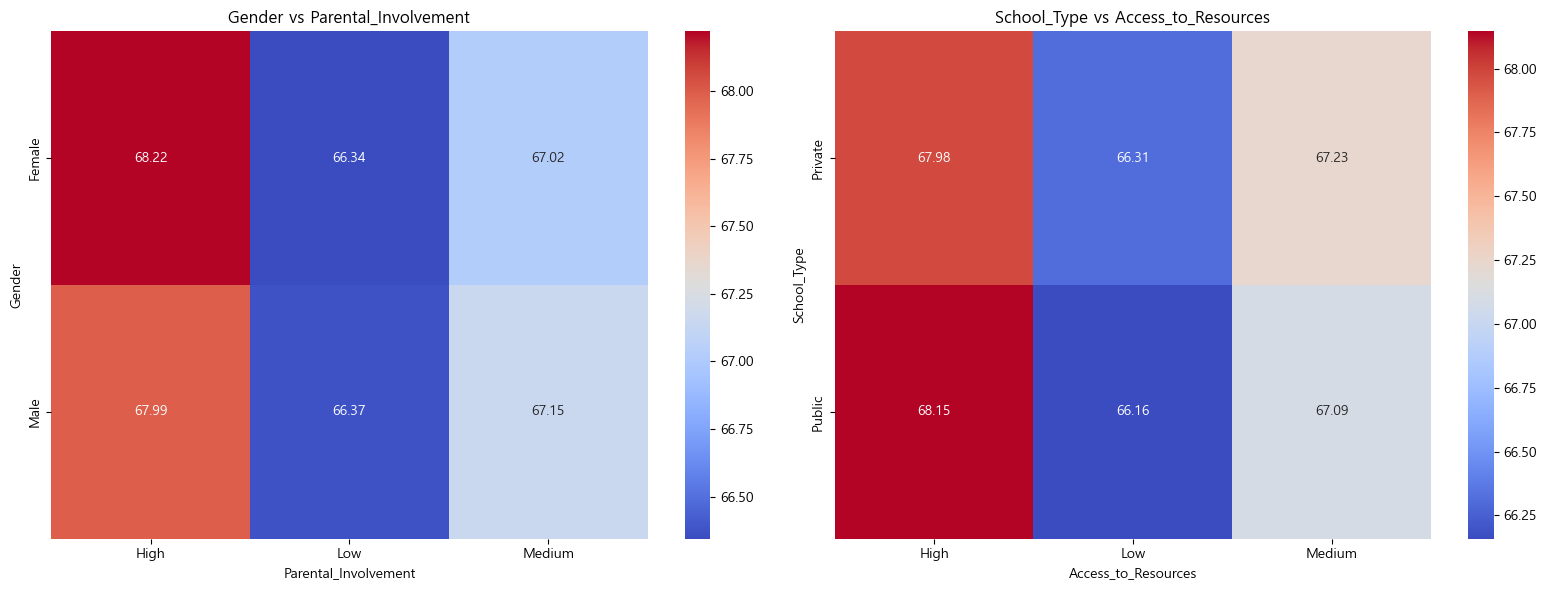

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_df1, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[0])
ax[0].set_title("Gender vs Parental_Involvement")

sns.heatmap(pivot_df2, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1])
ax[1].set_title("School_Type vs Access_to_Resources")

plt.tight_layout()
plt.show()

## 데이터 전처리

In [82]:
# 결측치가 범주형이므로 mode로 채우기
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

In [83]:
# 100점이 넘는 이상치는 100점으로 대체
df.loc[df['Exam_Score']>100, 'Exam_Score']=100

- 순서가 있는 변수는 Ordinal Encoding을 적용하고, 순서가 없는 변수는 One-Hot Encoding을 적용하였다.
- 수치형 변수는 모델 성능 향상을 위해 표준화(StandardScaler)를 수행하였다.

In [84]:
# label encoding (for ordered categories)
from sklearn.preprocessing import OrdinalEncoder

ordered_columns = {
    'Parental_Involvement': ['Low', 'Medium', 'High'],
    'Access_to_Resources': ['Low', 'Medium', 'High'],
    'Motivation_Level': ['Low', 'Medium', 'High'],
    'Family_Income': ['Low', 'Medium', 'High'],
    'Teacher_Quality': ['Low', 'Medium', 'High'],
    'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home': ['Near', 'Moderate', 'Far']
}

encoder = OrdinalEncoder(categories=list(ordered_columns.values()))

df[list(ordered_columns.keys())] = encoder.fit_transform(
    df[list(ordered_columns.keys())]
)

In [85]:
# one-hot (for nominal/unordered categories)
nominal_cols = [
    'Gender',
    'Internet_Access',
    'Extracurricular_Activities',
    'Learning_Disabilities',
    'School_Type'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [ ]:
# 정규화
from sklearn.preprocessing import StandardScaler, OneHotEncoder
cols_to_scale=['Hours_Studied','Attendance','Previous_Scores']
scaler=StandardScaler()
scaler.fit(df[cols_to_scale])
df[cols_to_scale]=scaler.transform(df[cols_to_scale])

## 요약 및 인사이트 도출
EDA 결과, 시험 성적은 출석률(Attendance)과 공부 시간(Hours_Studied)과 같은 학습 행동 변수와 가장 강한 양의 관계를 보였으며, 이전 성적(Previous_Scores)과 과외 횟수(Tutoring_Sessions) 역시 일정 수준의 영향을 미치는 것으로 나타났다. 반면 수면 시간(Sleep_Hours)은 성적과 뚜렷한 관계를 보이지 않았다.

범주형 변수 분석에서는 부모의 학습 관여도(Parental_Involvement), 학습 자원 접근성(Access_to_Resources), 학습 동기(Motivation_Level), 교사 수준(Teacher_Quality)과 같은 교육 환경 요인이 높을수록 시험 성적이 높은 경향을 보였다. 또한 인터넷 접근성과 과외활동 참여 여부 역시 성적에 긍정적인 영향을 미쳤다.

반면 성별(Gender)과 학교 유형(School_Type)은 시험 성적에 큰 영향을 미치지 않는 것으로 나타났다. 이는 학업 성취도가 개인의 학습 습관과 환경에 더 크게 영향을 받는다는 점을 시사한다.

또한 일부 변수에서 이상치가 관찰되었으며, 특히 Exam_Score의 100점 초과 값은 비현실적인 값으로 판단되어 상한값 100으로 처리하였다.

종합적으로 본 데이터셋에서는 학생의 성적은 인구통계학적 요인보다 학습 행동 및 교육 환경 요인에 의해 더 크게 설명된다는 결론을 도출할 수 있다.

## 모델링 방향 제시
선형 회귀로 기본 관계 확인 후, 트리 기반 모델로 성능을 개선하는 방향으로 모델링을 진행